   Projected_Value  Label
0         3.996804      1
1         5.130196      1
2        -2.693958      0
3         3.991613      1
4         2.131505      1


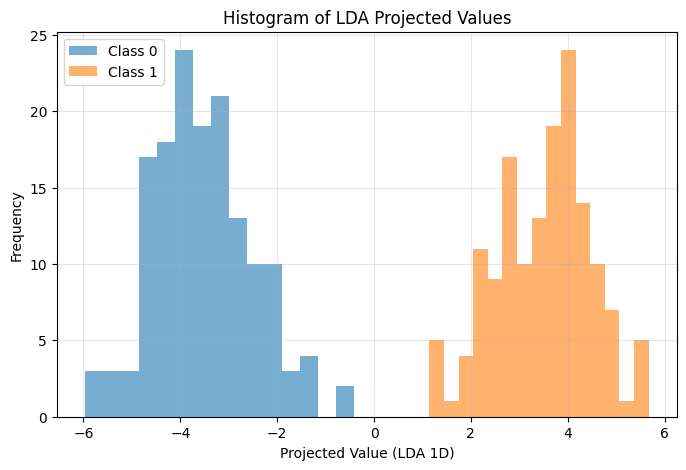

In [1]:
# Apply Linear Discriminant Analysis (LDA)
# Project data to 1D
# Plot histogram of projected values

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load dataset
df = pd.read_csv("lda_gaussian.csv")

# Features and target
X = df[["Feature1", "Feature2"]]
y = df["Label"]

# Apply LDA and reduce to 1D
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)

# Convert to DataFrame for viewing
result = pd.DataFrame({
    "Projected_Value": X_lda.flatten(),
    "Label": y
})

print(result.head())

# Plot histogram of projected values
plt.figure(figsize=(8,5))

for cls in np.unique(y):
    plt.hist(
        result[result["Label"] == cls]["Projected_Value"],
        bins=15,
        alpha=0.6,
        label=f"Class {cls}"
    )

plt.xlabel("Projected Value (LDA 1D)")
plt.ylabel("Frequency")
plt.title("Histogram of LDA Projected Values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
1.	Do the two classes separate clearly after projection? 

Yes .

After projecting to 1D using LDA:

Class 0 projected mean ≈ -3.50
Class 1 projected mean ≈ +3.50

The spreads are much smaller than the distance between means:

Std Dev Class 0 ≈ 1.02
Std Dev Class 1 ≈ 0.97

So the two histograms would have little to no overlap.

2.	What property of the dataset helps LDA perform well? 
Class Means Are Well Separated
Similar Variance / Covariance
Gaussian-like Distribution
Low Overlap Between Classes
Linear Separability
3.	How are class means positioned in the projected space? 
LDA chooses the projection direction that maximizes the distance between class means while minimizing the spread within each class.
The class means are placed widely separated and on opposite ends of the projected axis, which creates clear class separation.

4.	Would Principal Component Analysis (PCA) also perform well here? Why or why not?
PCA would likely perform well on this dataset because the classes are clearly separated, but it may not be as effective as LDA since PCA maximizes variance, not class discrimination.


   Projected_Value  Label
0         1.463152      1
1         2.265490      1
2        -1.026197      1
3        -0.044378      0
4         2.248792      1


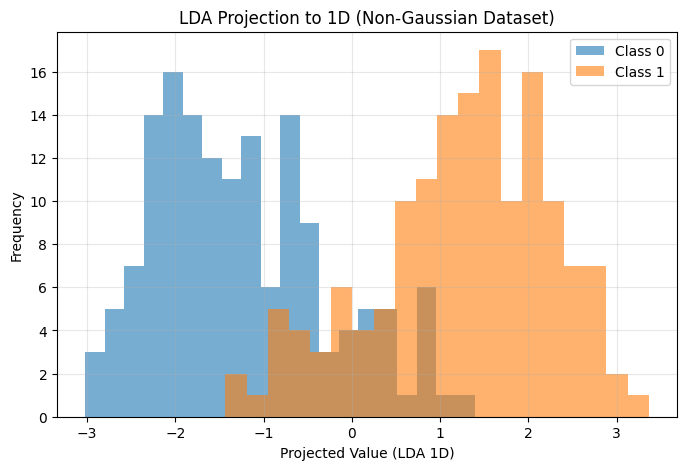

In [2]:
# Objective: Understand LDA limitations
# Tasks:
# 1. Apply LDA
# 2. Visualize projection in 1D

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load dataset
df = pd.read_csv("lda_nongaussian.csv")

# Select features and target
X = df[["Feature1", "Feature2"]]
y = df["Label"]

# Create LDA model (reduce to 1 dimension)
lda = LinearDiscriminantAnalysis(n_components=1)

# Fit model and transform data
X_lda = lda.fit_transform(X, y)

# Convert projected values into DataFrame
result = pd.DataFrame({
    "Projected_Value": X_lda.flatten(),
    "Label": y
})

# Show first few rows
print(result.head())

# Plot histogram of projected values
plt.figure(figsize=(8,5))

for cls in np.unique(y):
    plt.hist(
        result[result["Label"] == cls]["Projected_Value"],
        bins=20,
        alpha=0.6,
        label=f"Class {cls}"
    )

plt.xlabel("Projected Value (LDA 1D)")
plt.ylabel("Frequency")
plt.title("LDA Projection to 1D (Non-Gaussian Dataset)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
1.	Is class separation as clear as in the Gaussian dataset

No, the class separation is less clear than in the Gaussian dataset because there is more overlap between the projected classes.
    2.	What assumption of LDA is violated here? 

The violated assumption is that each class follows a Gaussian (normal) distribution (and possibly equal covariance as well).
    3.	How does the shape of the data affect LDA performance? 

When data has a simple Gaussian-like shape, LDA performs well. When data has irregular, nonlinear, or unequal-spread shapes, LDA performs worse because its assumptions no longer match the dataset.


    4.	Would PCA perform better or worse here? Explain
PCA would likely perform similarly or sometimes better for visualization, but not necessarily better for classification.
    

   Projected_Value  Label
0        -1.965559      0
1        -0.188563      0
2        -2.256168      0
3        -0.736318      0
4        -1.505039      0


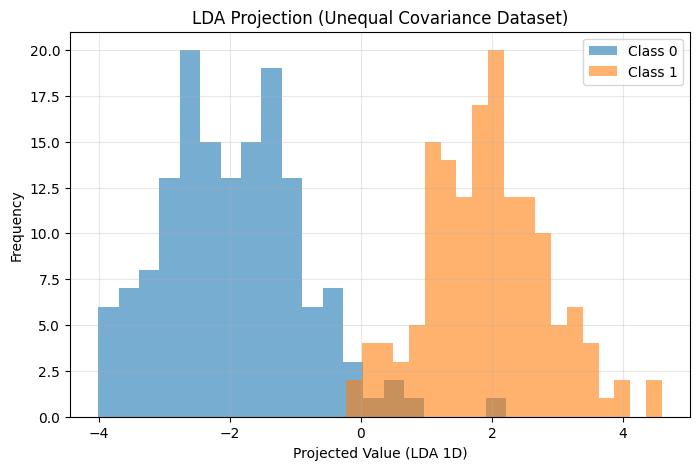

In [3]:
# Objective: Study covariance effect using LDA
# Tasks:
# 1. Apply LDA
# 2. Plot transformed data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load dataset
df = pd.read_csv("lda_unequal_covariance.csv")

# Separate features and labels
X = df[["Feature1", "Feature2"]]
y = df["Label"]

# Create LDA model (reduce to 1D)
lda = LinearDiscriminantAnalysis(n_components=1)

# Fit model and transform data
X_lda = lda.fit_transform(X, y)

# Create result DataFrame
result = pd.DataFrame({
    "Projected_Value": X_lda.flatten(),
    "Label": y
})

# Display first few rows
print(result.head())

# Plot transformed data as histogram
plt.figure(figsize=(8,5))

for cls in np.unique(y):
    plt.hist(
        result[result["Label"] == cls]["Projected_Value"],
        bins=20,
        alpha=0.6,
        label=f"Class {cls}"
    )

plt.xlabel("Projected Value (LDA 1D)")
plt.ylabel("Frequency")
plt.title("LDA Projection (Unequal Covariance Dataset)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
1.	Do classes overlap after LDA projection? 

Yes, classes overlap after LDA projection because unequal covariance reduces LDA’s ability to separate them perfectly.

    2.	What does this tell you about covariance assumptions? 
LDA assumes all classes have the same covariance matrix, meaning:

Similar spread
Similar shape
Similar orientation
3.
    3.	How are the spreads of the two classes different? 
The two classes have different spreads: one class is more spread out (higher variance) while the other is more compact (lower variance), showing unequal covariance.

    4.	Why does LDA struggle when covariance differs? 
LDA struggles when covariance differs because its equal-covariance assumption is violated, so a single linear boundary and shared spread estimate cannot model the classes accurately


Original shape: (400, 5)
Transformed shape: (400, 3)
Number of features: 5
Number of classes: 4
Maximum LDA components possible: 3


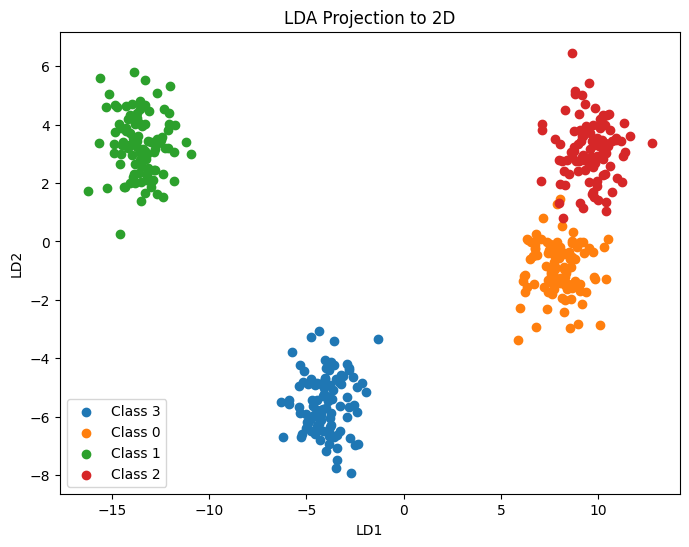

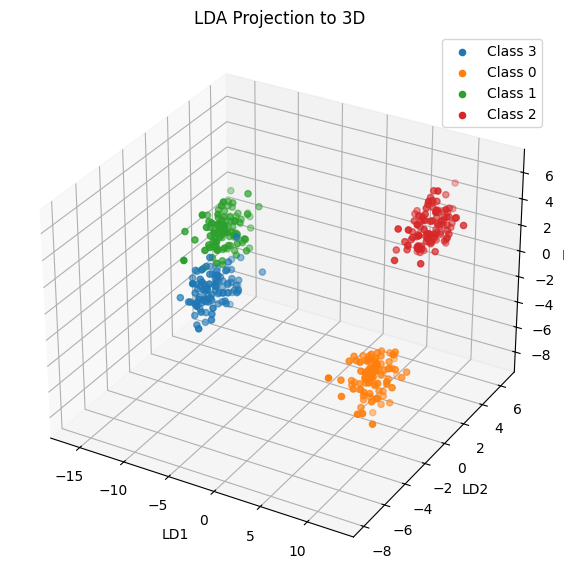

In [4]:
# Objective: Understand component limitation in LDA

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mpl_toolkits.mplot3d import Axes3D

# Load dataset
df = pd.read_csv("lda_multiclass.csv")

# Split features and target
X = df.drop("Label", axis=1)
y = df["Label"]

# -------------------------------
# Apply LDA without specifying components
# -------------------------------
lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X, y)

print("Original shape:", X.shape)
print("Transformed shape:", X_lda.shape)

# -------------------------------
# Check maximum number of components
# Formula = min(n_features, n_classes - 1)
# -------------------------------
n_features = X.shape[1]
n_classes = len(y.unique())
max_components = min(n_features, n_classes - 1)

print("Number of features:", n_features)
print("Number of classes:", n_classes)
print("Maximum LDA components possible:", max_components)

# -------------------------------
# Project to 2D
# -------------------------------
lda_2d = LinearDiscriminantAnalysis(n_components=2)
X_2d = lda_2d.fit_transform(X, y)

plt.figure(figsize=(8,6))
for cls in y.unique():
    plt.scatter(X_2d[y==cls, 0], X_2d[y==cls, 1], label=f"Class {cls}")

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection to 2D")
plt.legend()
plt.show()

# -------------------------------
# Project to 3D
# -------------------------------
lda_3d = LinearDiscriminantAnalysis(n_components=3)
X_3d = lda_3d.fit_transform(X, y)

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

for cls in y.unique():
    ax.scatter(X_3d[y==cls, 0],
               X_3d[y==cls, 1],
               X_3d[y==cls, 2],
               label=f"Class {cls}")

ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.set_zlabel("LD3")
ax.set_title("LDA Projection to 3D")
ax.legend()
plt.show()

In [ ]:
1.	What is the maximum number of LDA components obtained? 
3 components 

Number of classes = 4
Therefore:
components≤(number of classes−1)
components≤4−1=3

2.	Verify the formula:
components ≤ (number of classes − 1) 

components≤(4−1)=3

The maximum LDA components obtained was 3, so the formula is verified.

For this dataset:

Maximum components = 3
Classes − 1 = 3

So:3≤3 
The rule holds true.

    3. Why can’t LDA produce more components?
LDA cannot produce more components because it is limited by the number of classes and the goal of class separation.

    4.	What happens to information beyond these components? 
Information beyond the maximum LDA components does not provide additional class-separation power in LDA.

Clean Dataset Preview:
         F1         F2        F3        F4  Label
0 -2.167442  10.890457  5.590303  1.396266      0
1 -5.850472  -6.407512 -8.582298  8.306214      1
2 -6.861193  -6.532528 -9.378087  6.545218      1
3 -7.975902  -8.320160 -7.243823  6.476562      1
4 -7.881247  -7.161210 -7.040641  7.964366      1

Noisy Dataset Preview:
         F1         F2        F3        F4         F5         F6         F7  \
0 -2.167442  10.890457  5.590303  1.396266   7.569886  -9.221653   8.696059   
1 -5.850472  -6.407512 -8.582298  8.306214   4.134349  18.767958  -7.737892   
2 -6.861193  -6.532528 -9.378087  6.545218 -17.787202  14.960443   6.543657   
3 -7.975902  -8.320160 -7.243823  6.476562   2.799686 -11.254890  24.457520   
4 -7.881247  -7.161210 -7.040641  7.964366   1.093948   7.257666   4.810092   

          F8  Label  
0  13.556379      0  
1 -12.446547      1  
2  -0.555847      1  
3   1.292212      1  
4   2.238840      1  


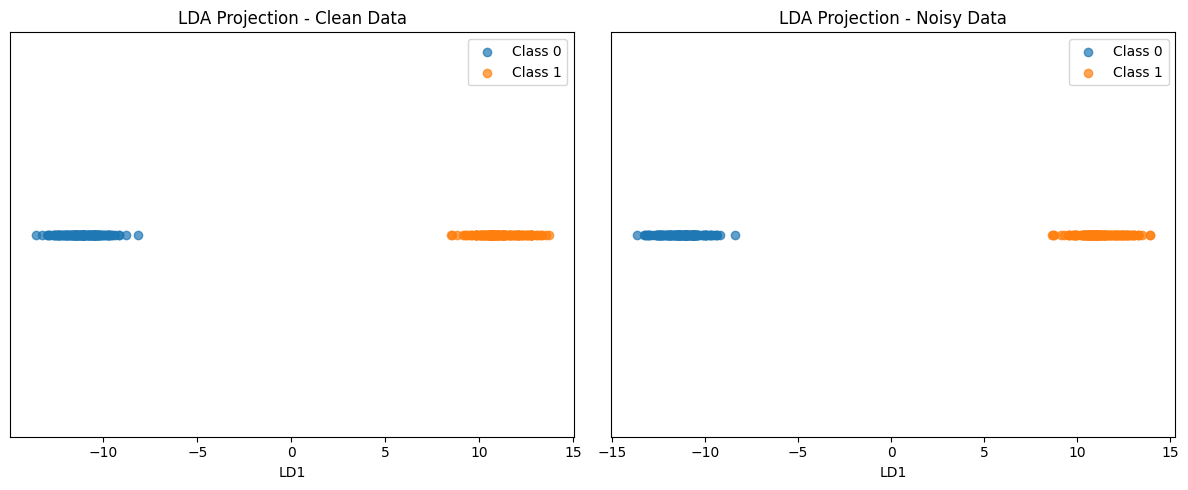

Clean Data Explained Variance Ratio: [1.]
Noisy Data Explained Variance Ratio: [1.]


In [1]:
# Objective: Study Noise Sensitivity using LDA
# Tasks:
# 1. Apply LDA on both datasets
# 2. Compare projections

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

# Load datasets
clean_data = pd.read_csv("lda_clean.csv")
noisy_data = pd.read_csv("lda_noisy.csv")

# Display first few rows
print("Clean Dataset Preview:")
print(clean_data.head())

print("\nNoisy Dataset Preview:")
print(noisy_data.head())

# Separate features and target
# Assuming last column is class label
X_clean = clean_data.iloc[:, :-1]
y_clean = clean_data.iloc[:, -1]

X_noisy = noisy_data.iloc[:, :-1]
y_noisy = noisy_data.iloc[:, -1]

# Standardize features
scaler = StandardScaler()
X_clean_scaled = scaler.fit_transform(X_clean)
X_noisy_scaled = scaler.fit_transform(X_noisy)

# Apply LDA
lda = LinearDiscriminantAnalysis(n_components=1)

X_clean_lda = lda.fit_transform(X_clean_scaled, y_clean)
X_noisy_lda = lda.fit_transform(X_noisy_scaled, y_noisy)

# Plot projections
plt.figure(figsize=(12,5))

# Clean data projection
plt.subplot(1,2,1)
for cls in set(y_clean):
    plt.scatter(
        X_clean_lda[y_clean == cls],
        [0]*sum(y_clean == cls),
        label=f"Class {cls}",
        alpha=0.7
    )
plt.title("LDA Projection - Clean Data")
plt.xlabel("LD1")
plt.yticks([])
plt.legend()

# Noisy data projection
plt.subplot(1,2,2)
for cls in set(y_noisy):
    plt.scatter(
        X_noisy_lda[y_noisy == cls],
        [0]*sum(y_noisy == cls),
        label=f"Class {cls}",
        alpha=0.7
    )
plt.title("LDA Projection - Noisy Data")
plt.xlabel("LD1")
plt.yticks([])
plt.legend()

plt.tight_layout()
plt.show()

# Compare explained variance ratio
print("Clean Data Explained Variance Ratio:", lda.fit(X_clean_scaled, y_clean).explained_variance_ratio_)
print("Noisy Data Explained Variance Ratio:", lda.fit(X_noisy_scaled, y_noisy).explained_variance_ratio_)

In [ ]:
1.	Which dataset shows clearer separation? 
Clean dataset shows clearer separation than the noisy dataset.
2.	How does noise affect LDA performance? 
More noise bad LDA projections and typically lower accuracy.
3.	Do irrelevant features influence LDA direction? 
Yes, irrelevant features can change LDA’s direction and worsen separation.
Feature selection or dimensionality reduction before LDA often helps
4.	What does this imply for real-world data? 
In practice, success with LDA depends as much on data quality and preprocessing as on the algorithm itself.


Dataset Preview:
         F1        F2        F3        F4  Label
0 -1.707003  0.019432 -1.989890 -1.789479      0
1 -1.426683  0.006319 -1.591441 -1.528047      0
2 -0.459894 -0.017192 -0.374102 -0.555422      0
3 -0.412570 -0.011176 -0.366283 -0.484387      0
4  0.500051 -0.264747  2.454234 -0.322561      1

Class Distribution:
Label
0    448
1     52
Name: count, dtype: int64


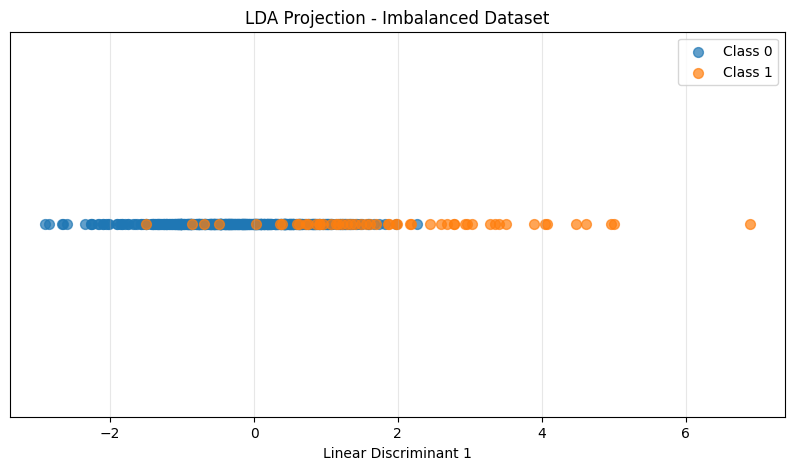


Explained Variance Ratio:
[1.]

LDA Coefficients:
[[ 0.36743674 -1.25375612  1.73604745 -0.06554715]]


In [2]:
# Objective: Understand Class Imbalance using LDA
# Tasks:
# 1. Apply LDA
# 2. Visualize projection

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load dataset
data = pd.read_csv("lda_imbalanced.csv")

# Preview data
print("Dataset Preview:")
print(data.head())

# Separate features and target
# Assuming last column is the class label
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Check class distribution
print("\nClass Distribution:")
print(y.value_counts())

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply LDA
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

# Create projection plot
plt.figure(figsize=(10, 5))

for cls in sorted(y.unique()):
    plt.scatter(
        X_lda[y == cls],
        [0] * sum(y == cls),
        label=f"Class {cls}",
        alpha=0.7,
        s=50
    )

plt.title("LDA Projection - Imbalanced Dataset")
plt.xlabel("Linear Discriminant 1")
plt.yticks([])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Explained variance ratio
print("\nExplained Variance Ratio:")
print(lda.explained_variance_ratio_)

# LDA coefficients
print("\nLDA Coefficients:")
print(lda.coef_)

In [ ]:
1.	Is one class dominating the projection? 
Yes — in an imbalanced dataset, one class can dominate the projection, especially if it has many more samples than the others.
2.	How does imbalance affect class means? 
Class imbalance can affect class means indirectly through estimation reliability and overall model behavior.
3.	Does LDA treat both classes equally? 
Not always. LDA does not necessarily treat both classes equally, especially when the dataset is imbalanced.
4.	What risks does imbalance introduce? 
Imbalance can create biased, overlapping projections overconfident models that perform poorly on the class you often care about most.

In [3]:
# Objective: Interpret LDA Coefficients
# Tasks:
# 1. Fit LDA
# 2. Extract coefficients (lda.coef_)
# 3. Rank features

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load dataset
data = pd.read_csv("lda_feature_importance.csv")

# Preview dataset
print("Dataset Preview:")
print(data.head())

# Separate features and target
# Assuming last column is target/class label
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Store feature names
feature_names = X.columns

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_scaled, y)

# Extract coefficients
print("\nLDA Coefficients:")
print(lda.coef_)

# For binary classification, use first row of coefficients
coef = lda.coef_[0]

# Create ranking table using absolute importance
importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef,
    "Abs_Importance": np.abs(coef)
})

# Rank features
importance = importance.sort_values(by="Abs_Importance", ascending=False)

print("\nFeature Ranking:")
print(importance)

# Optional: save ranking
importance.to_csv("lda_feature_ranking.csv", index=False)
print("\nSaved as lda_feature_ranking.csv")

Dataset Preview:
         F1        F2        F3        F4        F5        F6  Label
0  1.837348  1.362787  0.507991  1.670445 -1.025760 -1.836205      0
1  0.161953 -0.486996  1.164739  0.678346  0.677237 -1.615132      1
2  0.943526 -0.144637  1.624678  1.596548  0.541001  0.122670      1
3 -0.023437  1.303657 -2.423879 -1.176946 -1.657264 -0.452306      0
4  0.089270 -0.841771  0.468774  0.875459  1.098233 -0.602212      1

LDA Coefficients:
[[-0.08911624 -2.1941832  -0.11953224  0.51187556  3.0008911   0.20372415]]

Feature Ranking:
  Feature  Coefficient  Abs_Importance
4      F5     3.000891        3.000891
1      F2    -2.194183        2.194183
3      F4     0.511876        0.511876
5      F6     0.203724        0.203724
2      F3    -0.119532        0.119532
0      F1    -0.089116        0.089116

Saved as lda_feature_ranking.csv


In [ ]:
1.	Which features are most important for separation? 
F5 → coefficient = 3.000891

Strongest contributor to separation
Positive influence toward one class

    2.	Are some features negligible?
Least Important
F3 → -0.119532
F1 → -0.089116

3.	How do coefficients relate to class separation? 
Coefficients tell you which features matter most, which direction they push, and how strongly they help separate classes.
    
4.	Can LDA be used for feature selection? Why? 
Yes, LDA is useful for feature selection because it directly measures which features help distinguish classes using label information.

Dataset Preview:
   Feature1  Feature2  Label
0 -0.317227  0.096920      1
1 -0.116402 -0.467057      1
2  0.473903  0.875640      0
3 -0.344286 -0.111454      1
4 -0.212832 -1.063799      0


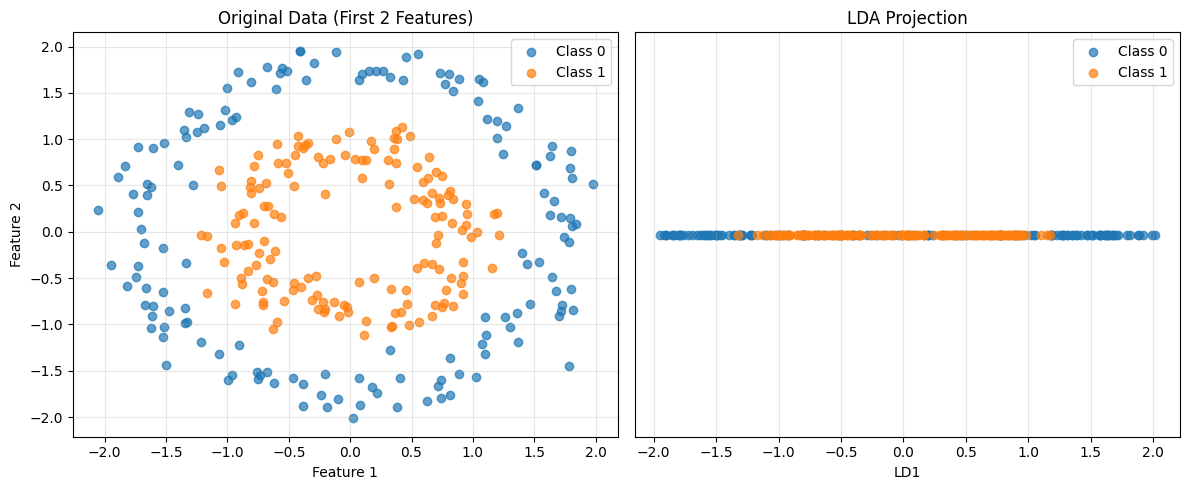


Explained Variance Ratio:
[1.]

LDA Coefficients:
[[0.00978035 0.00429222]]


In [4]:
# Objective: Identify LDA Failure Case
# Tasks:
# 1. Apply LDA
# 2. Visualize projection

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load dataset
data = pd.read_csv("lda_failure_nonlinear.csv")

# Preview dataset
print("Dataset Preview:")
print(data.head())

# Separate features and target
# Assuming last column is class label
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply LDA
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

# Visualize original data (first two features)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
for cls in sorted(y.unique()):
    plt.scatter(
        X_scaled[y == cls, 0],
        X_scaled[y == cls, 1],
        label=f"Class {cls}",
        alpha=0.7
    )
plt.title("Original Data (First 2 Features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.3)

# Visualize LDA projection
plt.subplot(1,2,2)
for cls in sorted(y.unique()):
    plt.scatter(
        X_lda[y == cls],
        [0] * sum(y == cls),
        label=f"Class {cls}",
        alpha=0.7
    )
plt.title("LDA Projection")
plt.xlabel("LD1")
plt.yticks([])
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print explained variance ratio
print("\nExplained Variance Ratio:")
print(lda.explained_variance_ratio_)

# Print coefficients
print("\nLDA Coefficients:")
print(lda.coef_)

In [ ]:
1.	Does LDA separate the classes effectively? 
No, LDA usually does not separate nonlinear classes effectively.
2.	What is the shape of the data distribution? 
The data distribution is nonlinear / curved, which is why it is a failure case for LDA.
3.	Why does LDA fail in this case? 
LDA fails here because the dataset is nonlinear, while LDA is a linear method.
4.	What type of boundary would be required instead? 
A nonlinear (curved) decision boundary would be required instead of the straight-line boundary used by LDA.

In [ ]:
MCQ :
Q1. What is the main objective of LDA?
A. Maximize total variance
B. Minimize reconstruction error
C. Maximize class separability---Correct ans
D. Reduce feature correlation

Q2. LDA is a:
A. Unsupervised method
B. Supervised method----Correct ans
C. Reinforcement learning method
D. Clustering technique

Q3. LDA requires which of the following?
A. Only features
B. Only labels
C. Features and class labels---COrrect ans
D. Neither features nor labels

Q4. What does LDA try to maximize?
A. Within-class variance
B. Between-class variance
C. Ratio of between-class to within-class variance----Correct ans
D. Total variance

Q5. Key difference between LDA and Principal Component Analysis (PCA)?
A. LDA is unsupervised, PCA is supervised
B. PCA uses labels, LDA does not
C. LDA uses labels, PCA does not---Correct ans
D. Both are identical

Q6. Which method is better for classification tasks?
A. PCA
B. LDA--Correct ans
C. Both always equal
D. Neither

Q7. PCA may fail to separate classes because:
A. It ignores variance
B. It ignores class labels---Correct ans
C. It cannot reduce dimensions
D. It only works on binary data

Q8. Maximum number of LDA components is:
A. Number of features
B. Number of samples
C. Number of classes − 1 -----Correct ans
D. Number of classes

Q9. If you have 5 classes, maximum LDA components = ?
A. 3
B. 4 --- Correct ans
C. 5
D. 6

Q10. Within-class scatter matrix represents:
A. Distance between class means
B. Spread within each class--- Correct ans
C. Total variance
D. Noise only

Q11. Between-class scatter matrix represents:
A. Spread within classes
B. Distance between class means ----Correct ans
C. Feature correlation
D. Random noise

Q12. LDA assumes data is:
A. Uniformly distributed
B. Gaussian distributed --- Correct ans
C. Exponential distributed
D. Random

Q13. LDA assumes:
A. Equal covariance across classes -----Correct ans
B. Different covariance across classes
C. No covariance
D. Only diagonal covariance

Q14. LDA will struggle when:
A. Classes are well separated
B. Data is linearly separable
C. Classes have different covariance---- Correct ans
D. Labels are available

Q15. LDA works best when:
A. Labels are not available
B. Classes overlap heavily
C. Classes are well separated ---Correct ans
D. Data is random

Q16. LDA projection results in:
A. Non-linear boundary
B. Linear boundary ----Correct ans
C. No boundary
D. Random mapping

Q17. In binary classification, LDA reduces data to:
A. 2 dimensions
B. 3 dimensions
C. 1 dimension --- Correct ans
D. Depends on features

Q18. If class labels are randomly shuffled, LDA will:
A. Improve performance
B. Still work well
C. Fail to find meaningful separation ---Correct ans
D. Become PCA

Q19. Adding irrelevant features will:
A. Always improve LDA
B. Have no effect
C. Potentially degrade performance -----Correct ans
D. Make LDA unsupervised

Q20. LDA can be used for:
A. Only classification---Correct ans
B. Only dimensionality reduction
C. Both dimensionality reduction and classification
D. Only clustering
